# SIM V2 3D — Phase A test: JAX full-wave FDTD on the 7th-floor model

**Goal.** Voxelize the static 3-D model and run **one** full-wave FDTD solve for a single band using
the JAX/XLA accelerator (`fw_fdtd_jax.simulate_jax`) — the physics-identical, device-portable port of
the SIM V3 scalar-wave engine (4–11× vs NumPy on CPU; ~10–50× more on a GPU).

**Where this sits.** FDTD is the offline **teacher** that generates training data; the 3-D U-Net is
the runtime **student**. This notebook exercises the teacher on the real geometry.

**Runs in Colab out of the box** — it ships a pre-voxelized grid (`phaseA_classes.npz`), so it solves
without uploading the 344 MB OBJ. **For speed pick a GPU runtime** (Runtime → Change runtime type →
GPU). If the repo is private, the clone cell needs a token (see the note in that cell).

> **Resolution note.** Coarse **λ/4** (`NPW=4`) so the whole floor solves in seconds (GPU) to ~1 min
> (CPU) — a *test* resolution (visibly dispersive). Fidelity is λ/8–λ/10 (Phase B, on GPU).
> Precision is **float32** for the physics (fp16/fp8 are unfit for the leapfrog).

In [1]:
# === Environment bootstrap: Colab or local ===
import sys
from pathlib import Path
try:
    import google.colab            # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    BRANCH = "sim-v2-3d-jax-phase-a"   # branch holding this code; set to "main" once merged
    REPO = Path("/content/indoor-walk-test")
    if not REPO.exists():
        # Public repo → clones directly. If PRIVATE, use a tokenized URL:
        #   https://<GITHUB_TOKEN>@github.com/cgm2179/indoor-walk-test.git
        !git clone --depth 1 -b {BRANCH} https://github.com/cgm2179/indoor-walk-test.git "{REPO}"
    # jax / scipy / matplotlib are preinstalled on Colab (jax is GPU-enabled there).
else:
    here = Path.cwd()
    REPO = next((p for p in [here, *here.parents] if (p / "Physics Engine").is_dir()),
                Path("/Users/cameronmickle/Documents/Indoor_Walk_Test_7-7"))

SIMV3 = REPO / "Physics Engine" / "2D" / "SIM V3"
NBDIR = REPO / "Physics Engine" / "3D Map Physics" / "SIM V2" / "Indoor"
assert SIMV3.is_dir(), f"SIM V3 stack not found under {REPO}"
sys.path.insert(0, str(SIMV3))
print("IN_COLAB:", IN_COLAB, "| REPO:", REPO)

IN_COLAB: False | REPO: /Users/cameronmickle/Documents/Indoor_Walk_Test_7-7


In [2]:
import time, json
import numpy as np
import jax
import matplotlib.pyplot as plt
from bands_v3 import get
from fullwave2d import FullWaveScene          # builds the ITU medium c(x) + loss
from fw_fdtd_jax import simulate_jax          # the JAX/XLA FDTD stepper (Phase A)

print("JAX backend:", jax.default_backend(), "| devices:", jax.devices())

JAX backend: cpu | devices: [CpuDevice(id=0)]


## 1 · Configuration

In [3]:
BAND       = "LTE_B71_617"   # 617 MHz — smallest/cheapest band (λ ≈ 48.6 cm)
NPW        = 4.0             # cells per wavelength: 4 = coarse TEST; 8–10 = fidelity (slow → GPU)
MAT_CLASS  = 2              # occupied voxels -> ITU concrete_masonry (lossy dielectric)
CROSSINGS  = 1.5           # domain crossings to run (steady-state envelope)
M_PER_UNIT = 0.01837683    # model-unit -> metre (from manifest_3d.json)

CACHE = NBDIR / "phaseA_classes.npz"          # shipped voxel grid (runs without the OBJ)
# Only needed if you want to RE-voxelize from the mesh (delete CACHE to force this):
OBJ = Path("/Users/cameronmickle/Downloads/Current Version Indoor 7th floor v2 "
           "Layout Version.obj/30b0dfab-447c-4c55-ba00-30f1f76add51.obj")

band = get(BAND)
print(f"band {band.label}  f={band.f_mhz:.0f} MHz  λ={band.wavelength_m*100:.1f} cm")

band LTE_B71_617  f=617 MHz  λ=48.6 cm


## 2 · Material grid (load cache, or voxelize the mesh)

FDTD runs on voxels, not triangles. The shipped cache is loaded by default. To rebuild from the mesh,
delete the cache and provide `OBJ`: occupancy is marked from **vertices + edge-midpoints + centroids**
(watertight for a dense mesh at coarse `h`), axes reordered to `(width, depth, height)`, occupied
cells tagged with one ITU class.

In [4]:
def parse_obj(path):
    verts, tris = [], []
    with open(path) as fh:
        for ln in fh:
            if ln[:2] == "v ":
                verts.append(ln[2:].split()[:3])
            elif ln[:2] == "f ":
                idx = [int(t.split("/")[0]) - 1 for t in ln.split()[1:]]
                for i in range(1, len(idx) - 1):            # fan-triangulate quads/ngons
                    tris.append((idx[0], idx[i], idx[i + 1]))
    return np.asarray(verts, np.float32), np.asarray(tris, np.int64)

def voxelize(V, F, h):
    V = (V - V.min(0)) * (M_PER_UNIT if (V.max(0) - V.min(0)).max() > 500 else 1.0)
    s0 = V.max(0) - V.min(0)
    Wax = int(np.argmax(s0)); Hax = int(np.argmin(s0)); Dax = 3 - Wax - Hax
    V = V[:, [Wax, Dax, Hax]]                                # -> width, depth, height
    span = V.max(0) - V.min(0); origin = V.min(0)
    dims = tuple(int(np.ceil(x / h)) + 1 for x in span)
    occ = np.zeros(dims, bool); da = np.asarray(dims)
    def mark(p):
        idx = np.floor((p - origin) / h).astype(np.int64)
        m = np.all((idx >= 0) & (idx < da), axis=1); idx = idx[m]
        occ[idx[:, 0], idx[:, 1], idx[:, 2]] = True
    mark(V)
    p0, p1, p2 = V[F[:, 0]], V[F[:, 1]], V[F[:, 2]]
    for a, b in ((p0, p1), (p1, p2), (p2, p0)):
        mark(0.5 * (a + b))                                  # edge midpoints
    mark((p0 + p1 + p2) / 3.0)                               # centroids
    return occ, span

h = band.wavelength_m / NPW
if CACHE.exists():
    d = np.load(CACHE); occ = d["occ"]; span = d["span"]; h = float(d["h"])
    print(f"loaded cached grid {occ.shape} from {CACHE.name}")
elif OBJ.exists():
    t0 = time.time(); V, F = parse_obj(OBJ)
    print(f"parsed {len(V):,} verts / {len(F):,} tris in {time.time()-t0:.1f}s")
    t0 = time.time(); occ, span = voxelize(V, F, h)
    np.savez_compressed(CACHE, occ=occ, span=span, h=h)
    print(f"voxelized in {time.time()-t0:.1f}s (cached -> {CACHE.name})")
else:
    raise FileNotFoundError(f"No cache at {CACHE} and no OBJ at {OBJ}. Provide one.")

classes = (occ.astype(np.int8) * MAT_CLASS)
print(f"grid {occ.shape} = {occ.size/1e6:.2f} M cells | occupancy {occ.mean()*100:.1f}% "
      f"| h={h*100:.1f} cm | extent {span[0]:.1f} x {span[1]:.1f} x {span[2]:.2f} m")

loaded cached grid (642, 325, 31) from phaseA_classes.npz
grid (642, 325, 31) = 6.47 M cells | occupancy 2.2% | h=12.1 cm | extent 77.8 x 39.3 x 3.58 m


## 3 · Place the transmitter and build the scene

`FullWaveScene` maps each material class to an ITU-P.2040 wave speed `c(x)` and per-cell loss
`γ = π·f·tanδ`, and sets the CFL-stable timestep. The Tx is the air cell nearest the floor centre at
mid-height.

In [5]:
k0 = occ.shape[2] // 2
air = np.argwhere(~occ[:, :, k0]); ctr = np.array(occ.shape[:2]) // 2
tc = air[np.argmin(((air - ctr) ** 2).sum(1))]
tx = (int(np.clip(tc[0], 2, occ.shape[0]-3)),
      int(np.clip(tc[1], 2, occ.shape[1]-3)), int(k0))

sim = FullWaveScene(classes, h, band.f_mhz, tx, source="cw")
steps = int(round(CROSSINGS * max(span) / 299_792_458.0 / sim.dt))
print(f"tx voxel {tx}  |  dt={sim.dt:.3e}s  CFL={sim.cfl():.3f} (must be < {1/np.sqrt(3):.3f})")
print(f"work = {classes.size/1e6:.1f} M cells x {steps} steps = "
      f"{classes.size*steps/1e9:.1f} G cell-updates")

tx voxel (321, 162, 15)  |  dt=1.170e-10s  CFL=0.289 (must be < 0.577)
work = 6.5 M cells x 3327 steps = 21.5 G cell-updates


## 4 · JAX full-wave FDTD solve

In [6]:
res = simulate_jax(sim, steps, warmup_frac=0.5, extract_phasor=True, dtype="float32")
U = res["phasor"]                                            # steady-state complex field
print(f"JAX FDTD solve on [{res['backend']}]: {res['dt_run']:.1f} s "
      f"({res['mcps']:.0f} Mcell-updates/s)  finite={res['finite']}")
print("On a Colab GPU this is ~10–50x faster — the Phase B data-gen teacher.")

JAX FDTD solve on [cpu]: 70.6 s (305 Mcell-updates/s)  finite=True
On a Colab GPU this is ~10–50x faster — the Phase B data-gen teacher.


## 5 · Visualize the field

Matplotlib for **field-data** slices (its strength); use PyVista / Plotly / three.js for the mesh
volume render. |U| in relative dB (99.5th-percentile ref).

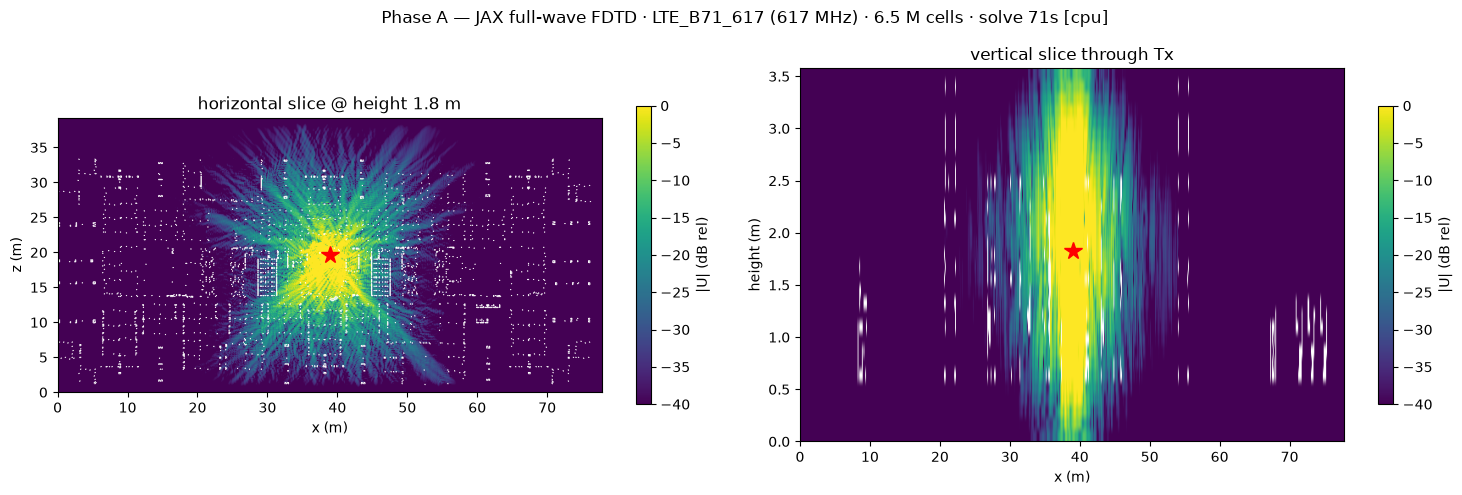

In [7]:
amp = np.abs(U); air3 = (classes == 0)
ref = np.percentile(amp[air3][amp[air3] > 0], 99.5)
db = 20 * np.log10(np.maximum(amp, ref * 1e-6) / ref)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
hz = np.where(air3[:, :, k0], db[:, :, k0], np.nan)
im0 = ax[0].imshow(hz.T, origin="lower", cmap="viridis", vmin=-40, vmax=0,
                   extent=[0, span[0], 0, span[1]], aspect="equal")
ax[0].contour(occ[:, :, k0].T, [0.5], colors="w", linewidths=0.3,
              extent=[0, span[0], 0, span[1]])
ax[0].plot(tx[0]*h, tx[1]*h, "r*", ms=13)
ax[0].set(title=f"horizontal slice @ height {tx[2]*h:.1f} m", xlabel="x (m)", ylabel="z (m)")
fig.colorbar(im0, ax=ax[0], shrink=0.8, label="|U| (dB rel)")

vt = np.where(air3[:, tx[1], :], db[:, tx[1], :], np.nan)
im1 = ax[1].imshow(vt.T, origin="lower", cmap="viridis", vmin=-40, vmax=0,
                   extent=[0, span[0], 0, span[2]], aspect="auto")
ax[1].plot(tx[0]*h, tx[2]*h, "r*", ms=13)
ax[1].set(title="vertical slice through Tx", xlabel="x (m)", ylabel="height (m)")
fig.colorbar(im1, ax=ax[1], shrink=0.8, label="|U| (dB rel)")

fig.suptitle(f"Phase A — JAX full-wave FDTD · {band.label} ({band.f_mhz:.0f} MHz) · "
             f"{classes.size/1e6:.1f} M cells · solve {res['dt_run']:.0f}s [{res['backend']}]")
fig.tight_layout(); fig.savefig(NBDIR / "phaseA_field.png", dpi=120, bbox_inches="tight"); plt.show()

## Next steps
- **Fidelity:** raise `NPW` to 8–10 (λ/8–λ/10) for quantitative physics — run on a GPU. Phase B
  (`Phase_B_datagen.ipynb`) automates this across many Tx.
- **Bands:** loop other `bands_v3` labels; whole-floor cost grows ~f⁴, so high bands need cropping.
- **Teacher → student:** crop 24³ complex boxes → fp16 shards → train the pure-JAX 3-D U-Net
  (`unet3d_jax.py`) in Phase C, then export ONNX via PyTorch.
- **Materials:** per-class voxelization (drywall vs concrete vs glass) via the production `voxelize.py`.